# **Wave Project**
### Introduction to using numpy and matplotlib to plot a wave and visualize transformations to it.

## *Basics of Numpy*

The goal of this project is to familiarize myself with numpy and matplotlib by plotting a simple sine wave and transforming it using
some simple wave equations. First things first, how the flip do I use numpy or matplotlib? import them yo!

In [2]:
import numpy as np
import matplotlib.pyplot as plt

ar = np.array([1, 2, 3, 4, 5, 6])

print(ar)

[1 2 3 4 5 6]


Nice! Now that we can see a basic example of numpy in action, what are the limitations to what can be included in an array?:
   - all elements must have the same type of data (int, str, float, etc.)
   - once created, the array size can't change
   - each row of an array must have the same number of columns (rectangular, not jagged)

Arrays can be transformed & mutated in multiple ways. Using standard python slice notation (a[x:y]) can be used, but slicing an array creates a view instead of a copy; the original array is still maintained but the output is a *'view'* of the mutated array.

In [3]:
mar = ar[:3]
print(mar)

bar = ar[2:5]
print(bar)

print(ar)

[1 2 3]
[3 4 5]
[1 2 3 4 5 6]


Two dimensional arrays can also be made easily using 'np.array':

In [4]:
twod = np.array([[1, 2, 3, 4], [2, 4, 6, 8], [3, 6, 9, 12]])
print(twod)

# each column and row in the array is organized by the same index rules or whatever it's called lol
# 'an element of an array can be accessed by specifying the index along each axis within a single set of brackets' - numpy devs
# array[x axis, y axis]

print(twod[2, 1])

[[ 1  2  3  4]
 [ 2  4  6  8]
 [ 3  6  9 12]]
6


## *Array Attributes*

There are four attributes to an array:
- .ndim (dimensions)
- .shape
- .size
- .dtype (data type)

.ndim will state the number of dimensions in an array, .shape details the number of elements along each dimension, .size states the number of elements in an array, and .dtype states the data type in the array.

In [6]:
print(twod)
print(twod.ndim)
print(twod.shape)
print(twod.size)
print(str(twod.dtype) + ': meaning 64-bit integer')

[[ 1  2  3  4]
 [ 2  4  6  8]
 [ 3  6  9 12]]
2
(3, 4)
12
int64: meaning 64-bit integer


## *Practice Applying it to a Wave*

I'm going to skip over some numpy fundamentals because honestly, I think the best way to learn these things is to dive in and making something! Trial by fire you could say. Real quick, I'm gonna detail the purpose of each module (method? function? im not gonna lie idrk the term) used in the code:
- np.linspace will be laying out our points on the 'x-axis' which will then be transformed by using the cosine function (np.cos) to form the wave.
- plt.plot(x,y) will just plot out the data according the functions assigned the x and y values (in this case, xaxis and yaxis)
- plt.x/ylim simply set the ranges of the x and y axis of the plot
- plt.title is literally what it says it is
- np.arange is set up like this: np.arange(start, stop, step). np.arange allows you to increase (or decrease probably) in a set interval; in this case i set the start value as '0' and the interval to 3, with the function stopping once it reaches a value of 36. Note: 'stop + step' (36 + 3) is useful in this case to ensure the set stop value is still represented in the graph.
- plt.axhline will just smack a line where you want on the x axis. The syntax for this is plt.axhline(y-intercept); additional information like color and line width can be added as seen below.
- plt.margins sets the margins of the plot. Not much to it
- plt.xticks sets the styling for the ticks (matplotlib with automatically create ticks but this is more for customization). [NOT TOTALLY CONFIDENT ABOUT THIS]
- plt.show displays the plot!

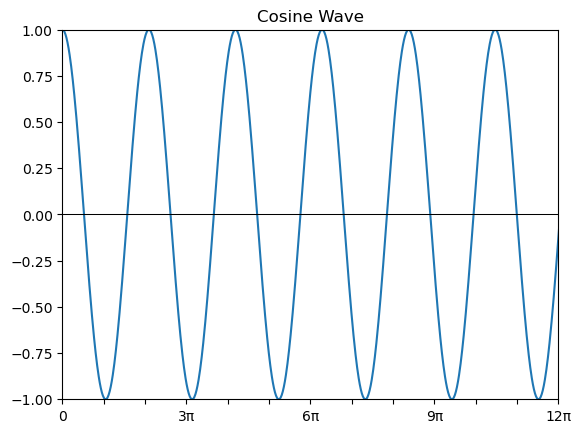

In [7]:
plt.xlim(0, 36)
plt.ylim(-1, 1)
xaxis = np.linspace(0, 12*np.pi, 1000)
yaxis = np.cos(xaxis)


def xtick(start, stop, step):       # defining the function used to set the tick marks on the x-axis. i wasn't satisfied with it presenting as 36 when it should be in radians.
    pos = np.arange(0, 36 + 3, 3)   # initially, the end value was ending at 36 (12*pi ~ 36) but i wanted to put it in radians. 
    labels = []
    for x in pos:
        n = round(x / 3)            # f(0) = 0/3 = 0 -> f(1) = 3/3 = 1 -> ... -> f(n) = x/3 = n
        if n == 0:
            labels.append('0')
        elif n % 3 != 0:            # 'If the remainder of 3 is not equal to 0, do not tag a value to the tick'
            labels.append(' ')
        else:
            labels.append(f'{n}π')  # tags pi next to 'n'; uses an f-string to use a integer variable in a string
    plt.xticks(pos, labels)

xtick(0, 36, 1)

plt.plot(xaxis,yaxis)
plt.axhline(0, color = 'black', linewidth = 0.75)
plt.title("Cosine Wave")
plt.margins(0.005)
plt.show()

Alrighty, there is a clear graph of a cosine wave! No fancy math behind the wave, but a headache behind the plot. I ran into multiple errors trying to format the plot, specifically the x-ticks. I was unaware that matplotlib creates the x-ticks based on the calculations that form the figure (can't change the tick marks without directly altering the mathematical function that forms the wave) so I had to get a little bit creative to put the x-axis in radians. Initially the x-axis was ending at 36 (12pi ~ 36) instead of 12pi, so I ended up creating the function 'xtick' to tailor each tick mark. The way 'xtick' works is by using the np.arange function to set the initial x value (0), the stop value (36), and the step increase (+3). So that already tells us the x-axis will have 12 marks (36/3), but they still won't be in radians. The key is to divide each value by 3 and then just tack on a pi symbol next to it (pi is always interpreted as it's numerical value otherwise). Perfect, we get our x-axis in radians! My only problem with this is that it still looked a little cluttered to me, so to remove some of the values, I added an elif statement that determines whether or not the output (n) is divisible by three and if it isn't, a blank space ' ' takes it's place on the tick. Now it looks just as I wanted it to look!